<a href="https://colab.research.google.com/github/michamettler/zhaw-xai/blob/main/04_Tutorial_Counterfactuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Influence Functions and Counterfactuals

### Influence functions

Influence functions are a tool from classical statistics that have been adapted to machine learning to understand how individual training points affect a model's predictions. They let us approximate the effect of removing or upweighting a specific training point on the model's parameters and outputs without retraining the model from scratch.\
Intuitively, we want to identify which training examples most influence a particular prediction or model behavior. The idea is that instead of retraining the model with each data point removed, we can use a mathematical shortcut based on the second-order Taylor expansion of the loss function.

The core quantity is the **influence of upweighting a training point $x$ on the loss at a test point $x_{\mathrm{test}}$**:

$$
\begin{align*}
I_{\mathrm{up,loss}}(x,x_{\mathrm{test}})
&:=\left.\frac{dL\big(x_{\mathrm{test}},\hat\theta_{\epsilon,x}\big)}{d\epsilon}\right|_{\epsilon=0}\\
&= \nabla_{\theta}L(x_{\mathrm{test}},\hat\theta)^{\top}
\left.\frac{d\hat\theta_{\epsilon,x}}{d\epsilon}\right|_{\epsilon=0}\\
&= -\nabla_{\theta}L(x_{\mathrm{test}},\hat\theta)^{\top}
H_{\hat\theta}^{-1}\,\nabla_{\theta}L(x,\hat\theta).
\end{align*}
$$

where:
- $\hat{\theta}$ are the learned model parameters,
- $\hat{\theta}_{\epsilon,x}$ are the parameters that would result from upweighting training point $x$ by a small amount $\epsilon$,
- $H_{\hat{\theta}} = \frac{1}{n}\sum_{i=1}^{n} \nabla_\theta^2 L(x_i, \hat{\theta})$ is the Hessian of the empirical risk at $\hat{\theta}$,
- $\nabla_{\theta} L(x,\hat{\theta})$ is the gradient of the loss at the training point $x$,
- $\nabla_{\theta} L(x_{\mathrm{test}},\hat{\theta})$ is the gradient of the loss at the test point $x_{\mathrm{test}}$.

In words, the first line defines the influence as the rate of change of the test loss when we upweight a training point $x$ by $\epsilon$. The second line applies the chain rule. The third line substitutes the closed-form expression for how the parameters change, yielding a dot product between the test gradient and the inverse-Hessian-weighted training gradient. The negative sign indicates that upweighting a helpful training point decreases the test loss.

Given a test point, we compute the influence of a training point using the inverse Hessian-vector product (iHVP).\
This is typically done with an iterative method like LiSSA (Linear time Stochastic Second-order Algorithm), since the full Hessian is too expensive to compute and store for large models.

In [ ]:
pip install medmnist dice-ml "pandas<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import medmnist
from medmnist import INFO
from torch.utils.data import DataLoader, Subset
from torchvision import models


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

import dice_ml

import warnings
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Loading the dataset

We will use the `dermamnist` dataset which contains images of skin lesions and their diagnoses.


In [ ]:
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[.5], std=[.5])
])

train_ds = DataClass(split='train', transform=transform, download=True)
test_ds = DataClass(split='test', transform = transform, download=True)

100%|██████████| 19.7M/19.7M [00:26<00:00, 740kB/s] 


#### Inspecting the class labels

Let's check the classes of the dataset.


In [ ]:
label_map = info['label']
print("Classes:")
for k, v in label_map.items():
    print(k, ":", v)

Classes:
0 : actinic keratoses and intraepithelial carcinoma
1 : basal cell carcinoma
2 : benign keratosis-like lesions
3 : dermatofibroma
4 : melanoma
5 : melanocytic nevi
6 : vascular lesions


#### Model training

We define a ResNet18 model and shortly train it to classify the images. We train the model for one epoch to have parameters suitable for computing influence functions. This is just enough to demonstrate the concept without requiring expensive computation.


In [ ]:
num_classes = len(label_map)

model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


model.train()
for epoch in range(1):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Computing gradients and the inverse Hessian-vector product

The following block defines the core functions needed to compute influence functions:

`get_grad_vector` computes the gradient of the loss with respect to all model parameters for a given input. This represents how much each parameter affects the loss for that example.

`hvp` computes the Hessian-vector product using PyTorch's autograd. The Hessian captures how the gradients themselves change with the parameters, and multiplying it by a vector is a key step in approximating influence functions efficiently.

`lissa_inverse_hvp` approximates the inverse Hessian-vector product using the LiSSA algorithm. It iteratively refines an estimate of the iHVP, which quantifies how much the model's loss at a test point would change if a training point were upweighted.


In [ ]:
def hvp(model, loss, params, v):
    """
    Hessian-vector product (HVP) using PyTorch autograd.
    """
    # First-order gradients of the loss w.r.t. model parameters
    grads = torch.autograd.grad(loss, params, create_graph=True)
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])

    # Compute the product H * v by differentiating (grad . v) w.r.t. params
    # This avoids forming the full Hessian matrix explicitly
    hv = torch.autograd.grad(grad_vector, params, grad_outputs=v, retain_graph=True)
    hv = torch.cat([h.contiguous().view(-1) for h in hv])

    return hv

def get_grad_vector(model, x, y):
    """Compute the gradient of the loss w.r.t. all model parameters for a single example."""
    model.zero_grad()
    outputs = model(x)

    y = y.view(-1).long()

    loss = criterion(outputs, y)
    # nabla_theta L(x, theta) -- this is the per-example gradient used in the influence formula
    grads = torch.autograd.grad(loss, model.parameters())
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])
    return grad_vector.detach()

def lissa_inverse_hvp(model, test_x, test_y, train_loader, damping=0.01, scale=25.0, recursion_depth=100):
    """
    LiSSA algorithm to approximate the inverse Hessian-vector product H^{-1} * v.
    Uses a Neumann series approximation to iteratively estimate H^{-1} * v
    without ever forming or inverting the Hessian matrix.
    """
    # v is the test gradient: nabla_theta L(x_test, theta)
    v = get_grad_vector(model, test_x, test_y).to(device)
    # Initialize the estimate as the test gradient itself
    cur_estimate = v.clone()

    for i in range(recursion_depth):
        # Sample a mini-batch from training data for stochastic approximation
        imgs, labels = next(iter(train_loader))
        imgs = imgs.to(device)
        labels = labels.squeeze().long().to(device)


        model.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        # Compute H * cur_estimate using the HVP function
        hv = hvp(model, loss, list(model.parameters()), cur_estimate)
        # LiSSA update: cur_estimate = v + (1 - damping) * cur_estimate - H * cur_estimate / scale
        cur_estimate = v + (1 - damping) * cur_estimate - hv / scale

    return cur_estimate


#### Selecting a test example and computing the iHVP

We select a test example and compute the approximate inverse Hessian-vector product (inv_hvp) for it. This corresponds to the $H_{\hat{\theta}}^{-1}\nabla_{\theta} L(x_{\mathrm{test}},\hat{\theta})$ term from the influence function formula and is the most expensive step of the computation.

In [ ]:
np.random.seed(42)
test_idx = 5
test_img, test_lbl = test_ds[test_idx]
test_img = test_img.to(device)
test_lbl = torch.tensor([int(test_lbl.squeeze())]).to(device)

# Compute H^{-1} * nabla_theta L(x_test, theta) using LiSSA
inv_hvp = lissa_inverse_hvp(model, test_img.unsqueeze(0), test_lbl, train_loader)


#### Computing influence scores for training points

For a subset of training data, we compute the influence of each point on the test example by taking the dot product of inv_hvp and the training point gradient. This tells us which training points most affect the test prediction.


In [ ]:
subset_size = 1500
train_indices = np.random.choice(len(train_ds), subset_size, replace=False)
train_subset = Subset(train_ds, train_indices)
train_loader_sub = DataLoader(train_subset, batch_size=1, shuffle=False)

influences = []

for idx, (img, lbl) in enumerate(train_loader_sub):
    img = img.to(device)
    lbl = lbl.view(-1).long().to(device)

    # Compute the gradient of this training point
    grad_z = get_grad_vector(model, img, lbl)

    # Influence = - (H^{-1} * grad_test) . grad_train
    # A high positive value means this training point strongly pushes the prediction
    influence = -torch.dot(inv_hvp, grad_z).item()
    influences.append((influence, idx))


#### Visualizing the most influential training examples

We sort the influence scores and display the top 3 most influential training examples alongside the test image. This provides a visual explanation of which training data affected the prediction the most.


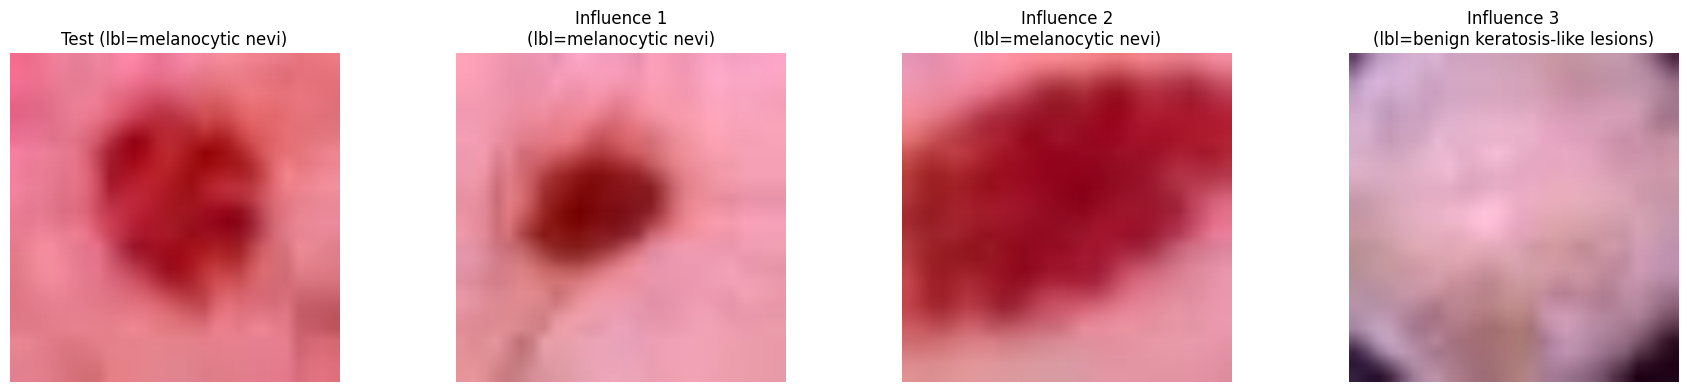

In [ ]:
topk = sorted(influences, key=lambda x: x[0], reverse=True)[:3]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

def show(img, ax, title):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

show(test_img.cpu(), axes[0], f"Test (lbl={label_map[str(int(test_lbl.squeeze()))]})")

for i, (_, idx) in enumerate(topk):
    img, lbl = train_subset[idx]
    show(img, axes[i + 1], f"Influence {i+1}\n(lbl={label_map[str(int(lbl.squeeze()))]})")

plt.tight_layout()
plt.show()

### Counterfactuals

Counterfactual explanations answer "What would need to change for the model to make a different decision?"
Given an input $x$ and a trained model, we seek a counterfactual $x'$ such that:
- the prediction flips
- $x'$ is as close as possible to $x$.

In practice, this becomes a constrained optimization problem balancing:

1. **Validity** -- the prediction changes to the desired outcome
2. **Proximity** -- the changes are minimal
3. **Plausibility** -- the counterfactual represents a realistic scenario

In this tutorial, we will use the **DiCE (Diverse Counterfactual Explanations)** library to generate counterfactuals instead of manual brute-force search loops. DiCE is a model-agnostic library that provides a clean, unified API for generating diverse counterfactual explanations. It supports multiple generation methods including gradient-based optimization, random sampling, and KD-tree search, and works with any ML framework (scikit-learn, TensorFlow, PyTorch). A key strength of DiCE is its ability to incorporate real-world constraints such as feature immutability, permitted ranges, and diversity requirements directly into the counterfactual generation process.

Documentation and examples: [https://interpret.ml/DiCE/](https://interpret.ml/DiCE/)


#### Loading the heart disease dataset

We load the Cleveland heart disease dataset from UCI and assign column names. This dataset is used to predict the presence of heart disease in a patient based on various medical attributes. The dataset has 13 features and a binary target.


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=column_names)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


#### Data preprocessing

We preprocess the dataset such that we replace missing values encoded as ? with NaN, convert numeric columns, and drop incomplete rows. This ensures the dataset can be safely used for modeling.


In [ ]:
df = df.replace('?', np.nan)
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])
df = df.dropna()
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


#### Training a logistic regression model

We split features into numerical and categorical, scale/encode them appropriately, then train a logistic regression model. This model will be used to generate counterfactual explanations.


In [ ]:
X = df.drop("target", axis=1)

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

y = df["target"]

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = [c for c in df.columns if c not in categorical_features + ['target']]

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8166666666666667
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



#### Selecting candidates for counterfactual explanation

In order to demonstrate counterfactuals, we will select test samples where the model predicted "disease" and we want to answer "what would need to change for the model to predict no disease?"


In [ ]:
# choose a candidate instance (predicted 1)
X_test_copy = X_test.copy()
X_test_copy["true"] = y_test.values
X_test_copy["pred"] = clf_pipeline.predict(X_test)

candidates = X_test_copy[(X_test_copy["pred"] == 1)]

In [ ]:
idx = candidates.index[1]
x_orig = X_test.loc[idx:idx]

print("Original prediction:", clf_pipeline.predict(x_orig)[0])
print("Probability of disease:", clf_pipeline.predict_proba(x_orig)[0, 1])

Original prediction: 1
Probability of disease: 0.9140543603210197


### Setting up DiCE

To use DiCE, we need to create two objects:
1. **`dice_ml.Data`** – describes the dataset (features, their types, outcome name)
2. **`dice_ml.Model`** – wraps the trained sklearn model

DiCE then uses these to generate counterfactuals via its `generate_counterfactuals()` method.

In [ ]:
# Prepare a combined dataframe for DiCE (training data + target)
train_df = X_train.copy()
train_df["target"] = y_train.values

# DiCE Data object: describes the feature space (which features are continuous, what the outcome is)
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numerical_features,
    outcome_name="target"
)

# DiCE Model object: wraps our trained sklearn pipeline so DiCE can query predictions
dice_model = dice_ml.Model(
    model=clf_pipeline,
    backend="sklearn"
)

# Create the explainer using the "random" method (generates CFs by random perturbation)
explainer = dice_ml.Dice(dice_data, dice_model, method="random")


### Baseline Counterfactual

The baseline counterfactual finds the closest instance that changes the model's decision. DiCE generates diverse counterfactuals using its optimization-based or random search approach, which replaces the manual brute-force loops.\
This type of counterfactual is useful for understanding model sensitivity, but the resulting explanations may be unrealistic or impractical in real-world settings.

In [ ]:
# Generate baseline counterfactuals with no feature constraints
# desired_class= means we want the prediction to flip (1 -> 0)
cf_baseline_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=0
)

cf_baseline_result.visualize_as_dataframe(show_only_changes=True)


100%|██████████| 1/1 [00:00<00:00,  2.55it/s]

Query instance (original outcome : 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,100.0,299.0,0.0,2.0,125.0,1.0,0.9,2.0,2.0,3.0,1



Diverse Counterfactual set (new outcome: 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,0.0,2.0,-,-,-,-,-,-,-,-,3.0,-,0.0


In [ ]:
cf_baseline = cf_baseline_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
cf_baseline.index = x_orig.index

print("Baseline CF prediction:", clf_pipeline.predict(cf_baseline)[0])
print("Prob:", clf_pipeline.predict_proba(cf_baseline)[0, 1])

all_features = [c for c in df.columns if c != "target"]

pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline_cf": cf_baseline.iloc[0]
}).loc[all_features]

Baseline CF prediction: 0
Prob: 0.3522382050399794


,original,baseline_cf
age,67.0,67.0
sex,1.0,0.0
cp,4.0,2.0
trestbps,100.0,100.0
chol,299.0,299.0
fbs,0.0,0.0
restecg,2.0,2.0
thalach,125.0,125.0
exang,1.0,1.0
oldpeak,0.9,0.9


The baseline counterfactual shows the minimal set of feature changes needed to flip the prediction from "disease" to "no disease", with no constraints on which features can change.
Looking at the table above, notice which features were modified, the algorithm is free to change anything, including features like age or sex that a patient cannot actually control.
This highlights why unconstrained counterfactuals, while useful for understanding model sensitivity, may not produce actionable explanations.

### Feasible counterfactuals

Feasible counterfactuals introduce actionability constraints, preventing changes to features that cannot be modified (e.g., age, sex, medical history). DiCE supports this directly through the `features_to_vary` parameter.\
This ensures that explanations correspond to actions a person could realistically take, making them more useful for decision support.

In [ ]:
# Define features that cannot be changed (e.g., age, sex are not actionable)
immutable_features = ["age", "sex", "cp", "fbs", "restecg"]
mutable_features = [f for f in X.columns if f not in immutable_features]

# Generate CFs that only modify mutable features via features_to_vary
cf_feasible_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=0,
    features_to_vary=mutable_features
)

cf_feasible_result.visualize_as_dataframe(show_only_changes=True)


100%|██████████| 1/1 [00:00<00:00,  2.98it/s]

Query instance (original outcome : 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,100.0,299.0,0.0,2.0,125.0,1.0,0.9,2.0,2.0,3.0,1



Diverse Counterfactual set (new outcome: 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,-,-,-,138.0,-,-,183.9,-,-,3.0,3.0,-,0.0


In [ ]:
cf_feasible = cf_feasible_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
cf_feasible.index = x_orig.index

print("Feasible CF prediction:", clf_pipeline.predict(cf_feasible)[0])
print("Probability:", clf_pipeline.predict_proba(cf_feasible)[0, 1])

pd.DataFrame({
    "original": x_orig.iloc[0],
    "feasible_cf": cf_feasible.iloc[0]
}).loc[all_features]

Feasible CF prediction: 1
Probability: 0.5172274290060211


,original,feasible_cf
age,67.0,67.0
sex,1.0,1.0
cp,4.0,4.0
trestbps,100.0,100.0
chol,299.0,138.0
fbs,0.0,0.0
restecg,2.0,2.0
thalach,125.0,183.9
exang,1.0,1.0
oldpeak,0.9,0.9


Notice how the feasible counterfactual differs from the baseline: features like age, sex, chest pain type, fasting blood sugar, and resting ECG are now locked and cannot change.
If the baseline counterfactual relied on changing any of these immutable features (e.g., changing sex or age), the feasible version is forced to find alternative changes among the remaining actionable features — such as cholesterol, blood pressure, max heart rate, or ST depression.
This makes the explanation more useful as actionable medical advice: it only suggests changes that a patient could realistically achieve through treatment or lifestyle modifications.

### Causal Feasibility

Causal counterfactuals enforce domain knowledge about cause–effect relationships between features. When one feature changes, downstream effects must also change in a consistent way.\
These constraints prevent implausible combinations of feature values and ensure the counterfactual represents a coherent physiological scenario, not just a mathematical solution.
We choose to set the following constraints:

trestbps → chol

Higher blood pressure is often correlated with higher cholesterol (risk-related).

trestbps → thalach

Higher blood pressure often reduces exercise capacity (lower max heart rate).

thalach → oldpeak

Lower max heart rate can increase ST depression (oldpeak).

oldpeak → thalach

Higher ST depression often reduces exercise capacity (lower max heart rate).

We first generate counterfactuals with DiCE using the feasibility constraints, then apply causal constraints as a post-processing step. This combines the efficiency of DiCE's search with domain-specific causal knowledge.

In [ ]:
def enforce_causal_constraints(x_cf, x_orig):
    """Apply domain-driven causal rules as a post-processing step on a counterfactual."""
    x_cf = x_cf.copy()

    # Causal rule 1: higher blood pressure -> cholesterol must not decrease
    if x_cf["trestbps"].values[0] > x_orig["trestbps"].values[0]:
        x_cf["chol"] = max(x_cf["chol"].values[0], x_orig["chol"].values[0])

    # Causal rule 2: higher blood pressure -> max heart rate must not increase
    if x_cf["trestbps"].values[0] > x_orig["trestbps"].values[0]:
        x_cf["thalach"] = min(x_cf["thalach"].values[0], x_orig["thalach"].values[0])

    # Causal rule 3: lower max heart rate -> exercise-induced ST depression must not decrease
    if x_cf["thalach"].values[0] < x_orig["thalach"].values[0]:
        x_cf["oldpeak"] = max(x_cf["oldpeak"].values[0], x_orig["oldpeak"].values[0])

    # Causal rule 4: higher ST depression -> max heart rate must decrease by at least 5
    if x_cf["oldpeak"].values[0] > x_orig["oldpeak"].values[0]:
        x_cf["thalach"] = min(x_cf["thalach"].values[0], x_orig["thalach"].values[0] - 5)

    return x_cf


In [ ]:
# Generate a larger pool of candidate CFs (25) with feasibility constraints
cf_causal_result = explainer.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=25, # not within the search anymore, therefore you have to submit size of pool
    desired_class=0,
    features_to_vary=mutable_features
)

causal_cfs = cf_causal_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"])

# Post-process each candidate: enforce causal rules, then keep only those
# that still flip the prediction after the causal adjustment
causal_candidates = []
for i in range(len(causal_cfs)):
    x_cf = causal_cfs.iloc[i:i+1].copy()
    x_cf.index = x_orig.index
    x_cf = enforce_causal_constraints(x_cf, x_orig)

    # Only keep if the prediction still flips after causal adjustment
    if clf_pipeline.predict(x_cf)[0] == 1:
        dist = np.linalg.norm(x_orig[numerical_features].values - x_cf[numerical_features].values)
        causal_candidates.append((dist, x_cf))

# Pick the closest valid causal CF, or fall back to the feasible CF with causal adjustment
if len(causal_candidates) == 0:
    print("No causally valid CF found among generated candidates. Using closest feasible CF with causal adjustment.")
    cf_causal = cf_feasible.copy()
    cf_causal = enforce_causal_constraints(cf_causal, x_orig)
else:
    causal_candidates.sort(key=lambda x: x[0])
    cf_causal = causal_candidates[0][1]

print("Causal CF prediction:", clf_pipeline.predict(cf_causal)[0])
print("Prob:", clf_pipeline.predict_proba(cf_causal)[0, 1])

pd.DataFrame({
    "original": x_orig.iloc[0],
    "feasible_cf": cf_feasible.iloc[0],
    "causal_cf": cf_causal.iloc[0]
}).loc[all_features]


100%|██████████| 1/1 [00:00<00:00,  1.57it/s]

Causal CF prediction: 1
Prob: 0.6955007393093167


,original,feasible_cf,causal_cf
age,67.0,67.0,67.0
sex,1.0,1.0,1.0
cp,4.0,4.0,4.0
trestbps,100.0,100.0,100.0
chol,299.0,138.0,168.5
fbs,0.0,0.0,0.0
restecg,2.0,2.0,2.0
thalach,125.0,183.9,143.7
exang,1.0,1.0,0.0
oldpeak,0.9,0.9,0.2


Compared to the feasible counterfactual, the causal version respects physiological dependencies between features.
For example, if the feasible CF suggested lowering blood pressure while simultaneously increasing cholesterol, the causal constraints would correct this since lower blood pressure should not lead to higher cholesterol.
As a result, the causal counterfactual may suggest larger or different changes than the feasible one, but the combination of changes is medically coherent and represents a scenario that could realistically occur in a patient.

### Data on manifold CF

Manifold counterfactuals restrict explanations to regions of the feature space supported by observed data. DiCE's `kdtree` method generates counterfactuals by finding nearby instances in the training data, ensuring the counterfactual lies on or near the data manifold.\
This avoids unrealistic extrapolations and produces counterfactuals that are both valid and statistically plausible.

In [ ]:
# Use KD-tree method: finds CFs among actual training instances (on-manifold)
# This ensures the CF is a real observed data point, not a synthetic one
explainer_kdtree = dice_ml.Dice(dice_data, dice_model, method="kdtree")

cf_manifold_result = explainer_kdtree.generate_counterfactuals(
    query_instances=x_orig,
    total_CFs=1,
    desired_class=0
)

cf_manifold_result.visualize_as_dataframe(show_only_changes=True)


100%|██████████| 1/1 [00:00<00:00,  5.18it/s]


Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,100.0,299.0,0.0,2.0,125.0,1.0,0.9,2.0,2.0,3.0,0



Diverse Counterfactual set (new outcome: 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
247,47.0,-,-,110.0,275.0,-,-,118.0,-,-,-,1.0,-,-


In [ ]:
manifold_cf = cf_manifold_result.cf_examples_list[0].final_cfs_df.drop(columns=["target"]).iloc[0:1]
manifold_cf.index = x_orig.index

print("Manifold CF prediction:", clf_pipeline.predict(manifold_cf)[0])

pd.DataFrame({
    "original": x_orig.iloc[0],
    "manifold_cf": manifold_cf.iloc[0]
}).loc[all_features]

Manifold CF prediction: 1


,original,manifold_cf
age,67.0,47.0
sex,1.0,1.0
cp,4.0,4.0
trestbps,100.0,110.0
chol,299.0,275.0
fbs,0.0,0.0
restecg,2.0,2.0
thalach,125.0,118.0
exang,1.0,1.0
oldpeak,0.9,1.0


The manifold approach uses a KD-tree to retrieve the nearest training data points that the model predicts as the desired class.  This means the counterfactual is based on a real observed patient from the training set, not a mathematically generated point.
However, DiCE may apply a post-hoc sparsity step that slightly adjusts continuous feature values to minimize the number of features that differ from the original instance, so the final result may not be an exact copy of a training record but remains very close to one.
The key advantage is that the counterfactual stays on or very near the data manifold — the region of the feature space where real patients actually exist — avoiding unrealistic feature combinations that purely synthetic methods might produce.

#### Comparing all counterfactual types

Let's take a look and compare the counterfactuals from all stages:


In [ ]:
pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline_cf": cf_baseline.iloc[0],
    "feasible_cf": cf_feasible.iloc[0],
    "causal_cf": cf_causal.iloc[0],
    "manifold_cf": manifold_cf.iloc[0]
}).loc[all_features]

,original,baseline_cf,feasible_cf,causal_cf,manifold_cf
age,67.0,67.0,67.0,67.0,47.0
sex,1.0,0.0,1.0,1.0,1.0
cp,4.0,2.0,4.0,4.0,4.0
trestbps,100.0,100.0,100.0,100.0,110.0
chol,299.0,299.0,138.0,168.5,275.0
fbs,0.0,0.0,0.0,0.0,0.0
restecg,2.0,2.0,2.0,2.0,2.0
thalach,125.0,125.0,183.9,143.7,118.0
exang,1.0,1.0,1.0,0.0,1.0
oldpeak,0.9,0.9,0.9,0.2,1.0


#### Visualizing feature changes across counterfactual types

We will visualize which features changed across the different types of counterfactuals.


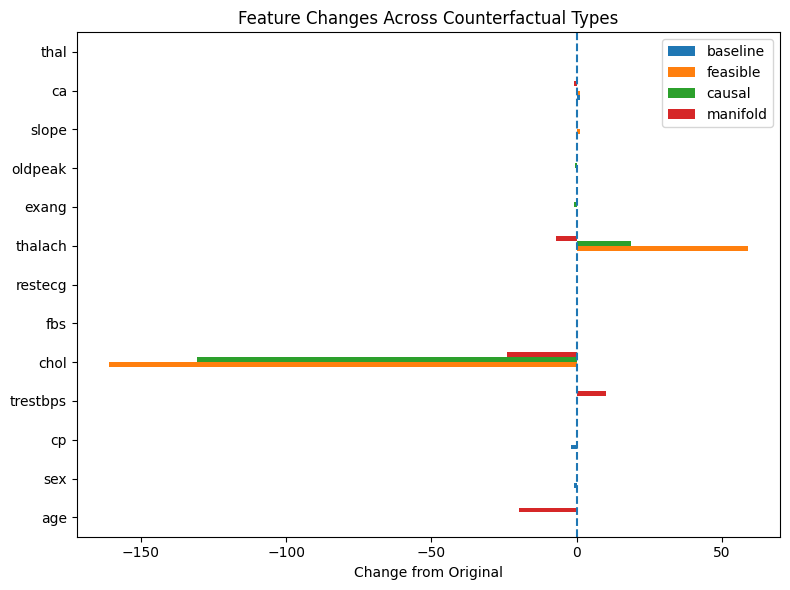

In [ ]:
import matplotlib.pyplot as plt

cf_df = pd.DataFrame({
    "original": x_orig.iloc[0],
    "baseline": cf_baseline.iloc[0],
    "feasible": cf_feasible.iloc[0],
    "causal": cf_causal.iloc[0],
    "manifold": manifold_cf.iloc[0]
}).loc[all_features]

delta_df = cf_df.drop(columns="original").subtract(cf_df["original"], axis=0)

delta_df.plot(kind="barh", figsize=(8, 6))
plt.axvline(0, linestyle="--")
plt.title("Feature Changes Across Counterfactual Types")
plt.xlabel("Change from Original")
plt.tight_layout()
plt.show()

#### PCA projection of manifold counterfactuals

To illustrate how manifold counterfactuals relate to real data, we can project the original instance, the manifold counterfactual and nearby positive-class samples into a two-dimensional space using PCA.


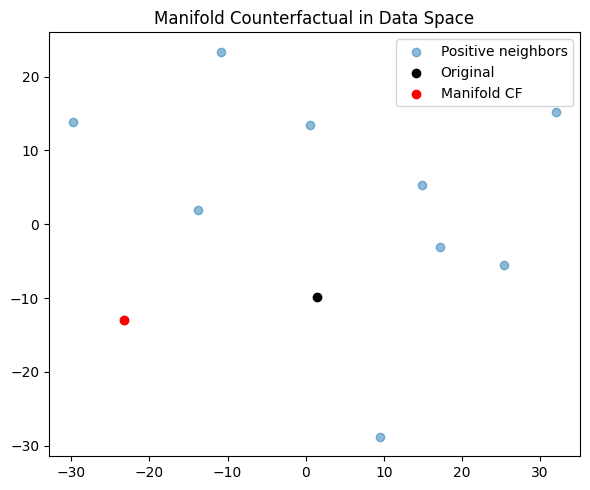

In [ ]:
from sklearn.neighbors import NearestNeighbors

X_train_pos = X_train[y_train == 1]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

nbrs = NearestNeighbors(n_neighbors=min(50, len(X_train_pos)-1), algorithm="ball_tree").fit(X_train_pos[numeric_features])
distances, indices = nbrs.kneighbors(x_orig[numeric_features])
neighbors = X_train_pos.iloc[indices[0]]

proj_data = pd.concat([
    x_orig,
    manifold_cf,
    neighbors.head(10)
])[numeric_features]

pca = PCA(n_components=2)
proj = pca.fit_transform(proj_data)

plt.figure(figsize=(6, 5))
plt.scatter(proj[2:, 0], proj[2:, 1], alpha=0.5, label="Positive neighbors")
plt.scatter(proj[0, 0], proj[0, 1], color="black", label="Original")
plt.scatter(proj[1, 0], proj[1, 1], color="red", label="Manifold CF")

plt.legend()
plt.title("Manifold Counterfactual in Data Space")
plt.tight_layout()
plt.show()

### Summary

In this tutorial, we explored two complementary explainable AI techniques: influence functions and counterfactual explanations, to understand why a model makes certain predictions and how those predictions could change.

Influence functions provide a training-data–centric explanation. Instead of focusing on input features, they trace a model's prediction back to the individual training samples that most affected it. By approximating the effect of upweighting or removing a training point (using inverse Hessian–vector products), influence functions help identify influential, supportive or potentially harmful data points. This is especially useful for debugging datasets, detecting mislabeled examples and understanding model behavior in sensitive domains like for example medical imaging.

Counterfactual explanations, on the other hand, are decision-centric. They answer the question: "What would need to change for the model to make a different decision?" Using the DiCE library, we generated counterfactuals with progressively stronger constraints: baseline, feasible, causal and manifold counterfactuals. DiCE replaces the manual brute-force search loops with efficient optimization-based and KD-tree-based methods.

In decision support, combining these approaches leads to explanations that are not only faithful to the model, but also actionable, plausible, and aligned with clinical intuition—key requirements for trustworthy and responsible AI.